# HumAID

[HumAID: Human-Annotated Disaster Incidents Data from Twitter](https://crisisnlp.qcri.org/humaid_dataset)

---

## A. Original

The HumAID Twitter dataset consists of several thousands of manually annotated tweets that has been collected during 19 major natural disaster events including earthquakes, hurricanes, wildfires, and floods, which happened from 2016 to 2019 across different parts of the World. The annotations in the provided datasets consists of following humanitarian categories. The dataset consists only english tweets and it is the largest dataset for crisis informatics so far.

### Humanitarian categories
- Caution and advice
- Displaced people and evacuations
- Dont know cant judge
- Infrastructure and utility damage
- Injured or dead people
- Missing or found people
- Not humanitarian
- Other relevant information
- Requests or urgent needs
- Rescue volunteering or donation effort
- Sympathy and support


### Ref

Firoj Alam, Umair Qazi, Muhammad Imran and Ferda Ofli, HumAID: Human-Annotated Disaster Incidents Data from Twitter, In ICWSM, 2021


## B. Data Processing

In [1]:
from pathlib import Path
import os
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

True

### B.1. Data Loading and Structural handling

In [2]:
events = {
    'canada_wildfires_2016': {
        'event_type':'wildfire',
        'event_name':'2016 Canada Wildfires',
        'year':'2016',
    },
    'california_wildfires_2018': {
        'event_type':'wildfire',
        'event_name':'2018 California Wildfires',
        'year':'2018',
    },
    'cyclone_idai_2019': {
        'event_type':'storm',
        'event_name':'Cyclone Idai',
        'year':'2019',
    },
    'ecuador_earthquake_2016': {
        'event_type':'earthquake',
        'event_name':'2016 Ecuador Earthquake',
        'year':'2016',
    },
    'greece_wildfires_2018': {
        'event_type':'wildfire',
        'event_name':'2018 Greece Wildfires',
        'year':'2018',
    },
    'hurricane_dorian_2019': {
        'event_type':'storm',
        'event_name':'Hurricane Dorian',
        'year':'2019',
    },
    'hurricane_florence_2018': {
        'event_type':'storm',
        'event_name':'Hurricane Florence',
        'year':'2018',
    },
    'hurricane_harvey_2017': {
        'event_type':'storm',
        'event_name':'Hurricane Harvey',
        'year':'2017',
    },
    'hurricane_irma_2017': {
        'event_type':'storm',
        'event_name':'Hurricane Irma',
        'year':'2017',
    },
    'hurricane_maria_2017': {
        'event_type':'storm',
        'event_name':'Hurricane Maria',
        'year':'2017',
    },
    'hurricane_matthew_2016': {
        'event_type':'storm',
        'event_name':'Hurricane Matthew',
        'year':'2016',
    },
    'maryland_floods_2018': {
        'event_type':'flood',
        'event_name':'2018 Maryland Floods',
        'year':'2018',
    },
    'midwestern_us_floods_2019': {
        'event_type':'flood',
        'event_name':'Midwestern US Floods',
        'year':'2019',
    },
    'italy_earthquake_aug_2016': {
        'event_type':'earthquake',
        'event_name':'2016 Italy Earthquake',
        'year':'2016',
    },
    'kaikoura_earthquake_2016': {
        'event_type':'earthquake',
        'event_name':'2016 Kaikoura Earthquake',
        'year':'2016',
    },
    'kerala_floods_2018': {
        'event_type':'flood',
        'event_name':'2018 Kerala Floods',
        'year':'2018',
    },
    'pakistan_earthquake_2019': {
        'event_type':'earthquake',
        'event_name':'2019 Pakistan Earthquake',
        'year':'2019',
    },
    'puebla_mexico_earthquake_2017': {
        'event_type':'earthquake',
        'event_name':'2017 Puebla Mexico Earthquake',
        'year':'2017',
    },
    'srilanka_floods_2017': {
        'event_type':'flood',
        'event_name':'2017 Sri Lanka Floods',
        'year':'2017',
    }
}

In [3]:
dataset_path = Path(os.getenv("DATASETS_PATH")) / 'HumAID'

base_dir = dataset_path / 'events_set'
all_files = sorted(base_dir.rglob('**/*.tsv'))

dfs = []
for file in all_files:
    parent_name = file.parent.name
    if parent_name not in events:
        print(f'Skipping: {parent_name}')
        continue
    data = events[parent_name]
    df = pd.read_csv(file, sep='\t', encoding='utf_8')
    df['tweet_id'] = df['tweet_id'].astype('int64')
    df['event_type'] = data['event_type']
    df['event_name'] = data['event_name']
    df['year'] = data['year']
    df['dataset'] = 'HumAID'
    df['meta'] = df.apply(
        lambda x: {
            'file_name': file.name,
            'sub_dataset': 'Crowdflower'
            },
        axis=1)
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

In [4]:
print(f'Total rows: {len(df)}')
df.head(10)

Total rows: 76484


,tweet_id,tweet_text,class_label,event_type,event_name,year,dataset,meta
0,733360620339257344,.@GreenABEnergy How can @AirworksCanada assist...,rescue_volunteering_or_donation_effort,wildfire,2016 Canada Wildfires,2016,HumAID,"{'file_name': 'canada_wildfires_2016_dev.tsv',..."
1,729520926795157504,RT @katvondawn: Thoughts &amp; prayers going t...,sympathy_and_support,wildfire,2016 Canada Wildfires,2016,HumAID,"{'file_name': 'canada_wildfires_2016_dev.tsv',..."
2,730739571739271168,Glacier Farm Media pledges $50K in support for...,rescue_volunteering_or_donation_effort,wildfire,2016 Canada Wildfires,2016,HumAID,"{'file_name': 'canada_wildfires_2016_dev.tsv',..."
3,733688875529293824,Beatton Airport Road wildfire in northern B.C....,infrastructure_and_utility_damage,wildfire,2016 Canada Wildfires,2016,HumAID,"{'file_name': 'canada_wildfires_2016_dev.tsv',..."
4,733046257090957312,RT @dana_balsor: @InsuranceBureau will Insur. ...,other_relevant_information,wildfire,2016 Canada Wildfires,2016,HumAID,"{'file_name': 'canada_wildfires_2016_dev.tsv',..."
5,729038418823372800,"RT @reporterchris: The @NHL is donating $100,0...",rescue_volunteering_or_donation_effort,wildfire,2016 Canada Wildfires,2016,HumAID,"{'file_name': 'canada_wildfires_2016_dev.tsv',..."
6,728915238121132032,"Foothills family, coming to the PDL game today...",rescue_volunteering_or_donation_effort,wildfire,2016 Canada Wildfires,2016,HumAID,"{'file_name': 'canada_wildfires_2016_dev.tsv',..."
7,735178846849404928,U.S. #wildfires have already burned 5 times as...,infrastructure_and_utility_damage,wildfire,2016 Canada Wildfires,2016,HumAID,"{'file_name': 'canada_wildfires_2016_dev.tsv',..."
8,730529189648982017,Ad Hoc Committee To Coordinate Federal Wildfir...,rescue_volunteering_or_donation_effort,wildfire,2016 Canada Wildfires,2016,HumAID,"{'file_name': 'canada_wildfires_2016_dev.tsv',..."
9,728746282903207936,RT @good_archer: #usanews New homes spring up ...,displaced_people_and_evacuations,wildfire,2016 Canada Wildfires,2016,HumAID,"{'file_name': 'canada_wildfires_2016_dev.tsv',..."


### B.2. Cleaning and Mapping
#### B.2.1. Remove duplicated

In [5]:
# No duplicate tweet_id found
print(f"Number of duplicate tweets id: {df['tweet_id'].duplicated().sum()}")

Number of duplicate tweets id: 0


In [6]:
print(f"Number of duplicate tweets text: {df['tweet_text'].duplicated().sum()}")

# Remove duplicates
df = df.drop_duplicates(subset=['tweet_text'])

Number of duplicate tweets text: 6


#### B.2.2. Map label

All lable is `Humanitarian aid` in crisis, so, all is `Positive` lable in **Binary Classification** Task

In [7]:
print(df['class_label'].value_counts())

class_label
rescue_volunteering_or_donation_effort    21276
other_relevant_information                12144
sympathy_and_support                       8928
infrastructure_and_utility_damage          8162
injured_or_dead_people                     7303
not_humanitarian                           6296
caution_and_advice                         5394
displaced_people_and_evacuations           3999
requests_or_urgent_needs                   2618
missing_or_found_people                     358
Name: count, dtype: int64


In [8]:
df.rename(columns={'class_label': 'original_humanitarian_label'}, inplace=True)
df['humanitarian_label'] = df['original_humanitarian_label']
df['informative'] = df['humanitarian_label'].apply(lambda x: (x != 'not_humanitarian'))

In [9]:
import csv
df.to_csv( '../data/datasets/HumAID.csv', index=False, quoting=csv.QUOTE_ALL)

### B.3. Verifying

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76478 entries, 0 to 76483
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   tweet_id                     76478 non-null  int64 
 1   tweet_text                   76478 non-null  object
 2   original_humanitarian_label  76478 non-null  object
 3   event_type                   76478 non-null  object
 4   event_name                   76478 non-null  object
 5   year                         76478 non-null  object
 6   dataset                      76478 non-null  object
 7   meta                         76478 non-null  object
 8   humanitarian_label           76478 non-null  object
 9   informative                  76478 non-null  bool  
dtypes: bool(1), int64(1), object(8)
memory usage: 5.9+ MB


In [11]:
df.describe(include='all')

,tweet_id,tweet_text,original_humanitarian_label,event_type,event_name,year,dataset,meta,humanitarian_label,informative
count,7.647800e+04,76478,76478,76478,76478,76478,76478,76478,76478,76478
unique,NaN,76478,10,4,19,4,1,57,10,2
top,NaN,.@GreenABEnergy How can @AirworksCanada assist...,rescue_volunteering_or_donation_effort,storm,Hurricane Irma,2017,HumAID,"{'file_name': 'hurricane_irma_2017_train.tsv',...",rescue_volunteering_or_donation_effort,True
freq,NaN,1,21276,45253,9399,28358,76478,6579,21276,70182
mean,9.807704e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.216041e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,7.215652e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,9.055327e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.021797e+18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.063967e+18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='informative'>

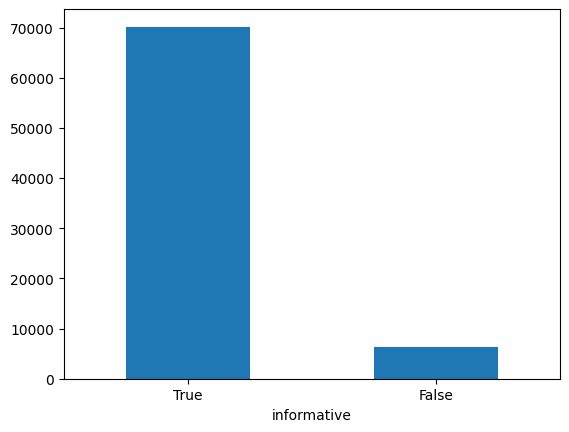

In [12]:
df['informative'].value_counts().plot(kind='bar', rot=0)

<Axes: xlabel='humanitarian_label'>

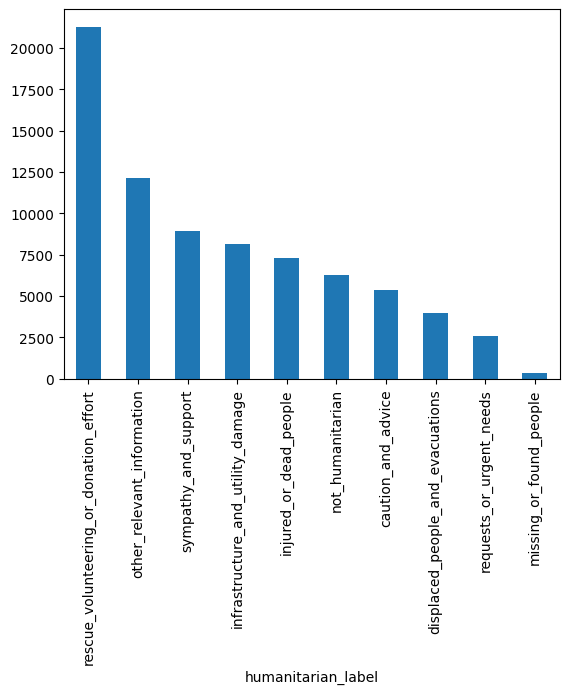

In [13]:
df['humanitarian_label'].value_counts().plot(kind='bar')

<Axes: xlabel='event_type'>

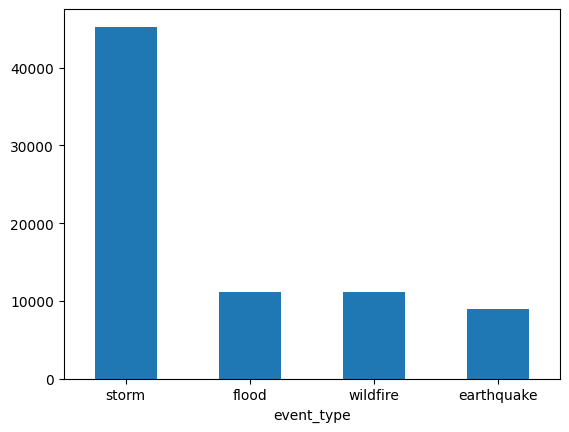

In [14]:
df['event_type'].value_counts().plot(kind='bar', rot=0)